[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/Quantlets/Ch_16/MFM_ch16_seminar/MFM_ch16_seminar.ipynb)

# Modelling Financial Markets — Seminar 16: Digital Assets and DeFi

*Seminar notebook. Daniel Traian Pele, Antoaneta Amza, Bucharest University of Economic Studies.*

- **[Solved]** problems contain the full solution; **[Proposed]** problems are solved by you.
- Part A: derivations (A1–A8); Part B: estimation and inference (B1–B8); Part C: open questions and AI critique (C1–C3).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_16'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


> Quantlet `MFM_ch16_seminar`: student version of the Seminar 16 notebook. Solved exercises (A1, A3, A5, A7, B1, B3, B5, B7) are shown with code and output; the proposed exercises (A2, A4, A6, A8, B2, B4, B6, B8, C1, C2, C3) are not solved here (an empty code cell where they need code).

> The solutions are discussed in the seminar.

In [ ]:
import os
import json
import time
import urllib.request
import urllib.parse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from scipy.signal import lfilter
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

## Style and helpers

In [ ]:
# Chart style: transparent background, legend below the plot
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Course colours (grey only for reference lines and the grid)
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Teal     = '#17A2B8'
Magenta  = '#D63384'
Brown    = '#795548'
Gray     = '#7F7F7F'
COL = {'BTC': Orange, 'ETH': Purple, 'XRP': MainBlue, 'ADA': Forest, 'DOGE': Amber, 'LTC': Teal, 'LINK': IDAred,
       'SOL': Magenta, 'BNB': Brown, 'SPX': MainBlue, 'GOLD': Amber, 'QQQ': Teal, 'USDT': Forest, 'USDC': MainBlue,
       'DAI': Orange, 'IBIT': MainBlue, 'ETHA': Purple, 'COIN': MainBlue, 'MSTR': IDAred, 'TLT': Forest}
CLASS_COL = {'Crypto': Orange, 'Equity': MainBlue, 'FX': Forest, 'Commodity': Amber, 'Bond': Purple}

HERE = '.'
SEED = 42
ETF_START = '2024-01-11'
B_BOOT = 2000


def save_fig(name):
    """Save the figure as a transparent PDF and PNG in the current folder."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Place the legend outside the plot, bottom centre."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=4, y=0.0):
    """A single legend below a multi-panel figure."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def jsonable(x):
    """Recursively convert numpy numbers and dates to JSON types."""
    if isinstance(x, dict):
        return {str(k): jsonable(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [jsonable(v) for v in x]
    if isinstance(x, (np.floating, float)):
        return None if not np.isfinite(x) else float(x)
    if isinstance(x, (np.integer,)):
        return int(x)
    if isinstance(x, (pd.Timestamp,)):
        return str(x.date())
    return x


def max_drawdown(p):
    """Largest fall from a previous peak (in %) and the date of the trough."""
    dd = p / p.cummax() - 1
    return 100 * dd.min(), dd.idxmin()


def hill(x, frac=0.05):
    """Hill estimator of the tail index from the largest frac of the positive values of x."""
    x = np.sort(x[x > 0])[::-1]
    k = max(int(frac * len(x)), 10)
    return 1 / np.mean(np.log(x[:k] / x[k]))


def hac_ols(y, X, lags=4):
    """OLS regression with Newey-West (HAC) standard errors."""
    return sm.OLS(y, sm.add_constant(X)).fit(cov_type='HAC', cov_kwds={'maxlags': lags})


import tempfile
# SAVE_TO_DRIVE = True (Colab cell above): charts and tables go to OUT_DIR in Google Drive; otherwise tables go to a temporary folder
KEEP = bool(globals().get('SAVE_TO_DRIVE', False))
HERE = globals().get('OUT_DIR', '.') if KEEP else tempfile.gettempdir()


def save_fig(name):
    """Show the figure; with SAVE_TO_DRIVE, also save it as PNG in OUT_DIR."""
    if KEEP:
        plt.savefig(os.path.join(HERE, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()


def _get(d, key):
    for part in key.split('/'):
        d = d[part]
    return d


def _fmt(v, digits=3):
    if isinstance(v, (bool, np.bool_)):
        return str(v)
    if isinstance(v, (int, np.integer)):
        return f'{int(v):,}'
    if isinstance(v, (float, np.floating)):
        return f'{float(v):,.{digits}f}'
    if isinstance(v, (list, tuple, np.ndarray)):
        return '[' + ', '.join(_fmt(x, digits) for x in v) + ']'
    return str(v)


def show(d, labels, digits=3, title=None):
    """Print selected results, one labelled line each."""
    if title:
        print(title)
    w = max(len(lab) for lab in labels.values())
    for k, lab in labels.items():
        print(f'  {lab:<{w}}  {_fmt(_get(d, k), digits)}')


def table(d, rows, cols=None, digits=3):
    """Table of selected results: rows with descriptive labels, columns renamed."""
    df = d if isinstance(d, pd.DataFrame) else pd.DataFrame(d)
    df = df.loc[list(rows)].rename(index=rows)
    if cols:
        df = df[list(cols)].rename(columns=cols)
    return df.apply(lambda c: c.map(lambda v: round(float(v), digits) if isinstance(v, (float, np.floating)) else v))

## Data

- Daily closes up to 18 September 2026: crypto-assets 7 days a week; ETFs and shares on weekdays, adjusted for dividends and splits.
- Coins in circulation: Coin Metrics Community Data; DeFi total value locked and stablecoin supply: DefiLlama.
- Analyses that combine assets use common days: prices are aligned on common trading days first, then returns are computed.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# read the course data
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'

# key -> (symbol, label, type, Coin Metrics id)
ASSETS = {
    'BTC': ('BTC-USD.CC', 'Bitcoin', 'crypto', 'btc'),
    'ETH': ('ETH-USD.CC', 'Ethereum', 'crypto', 'eth'),
    'XRP': ('XRP-USD.CC', 'XRP', 'crypto', 'xrp'),
    'BNB': ('BNB-USD.CC', 'BNB', 'crypto', None),
    'SOL': ('SOL-USD.CC', 'Solana', 'crypto', None),
    'ADA': ('ADA-USD.CC', 'Cardano', 'crypto', 'ada'),
    'DOGE': ('DOGE-USD.CC', 'Dogecoin', 'crypto', 'doge'),
    'LTC': ('LTC-USD.CC', 'Litecoin', 'crypto', 'ltc'),
    'LINK': ('LINK-USD.CC', 'Chainlink', 'crypto', 'link'),
    'USDT': ('USDT-USD.CC', 'Tether (USDT)', 'crypto', None),
    'USDC': ('USDC-USD.CC', 'USD Coin (USDC)', 'crypto', None),
    'DAI': ('DAI-USD.CC', 'Dai', 'crypto', None),
    'IBIT': ('IBIT.US', 'IBIT (spot Bitcoin ETF)', 'etf', None),
    'ETHA': ('ETHA.US', 'ETHA (spot Ether ETF)', 'etf', None),
    'COIN': ('COIN.US', 'Coinbase', 'etf', None),
    'MSTR': ('MSTR.US', 'Strategy', 'etf', None),
    'QQQ': ('QQQ.US', 'Nasdaq 100 (QQQ)', 'etf', None),
    'GLD': ('GLD.US', 'Gold (GLD)', 'etf', None),
    'TLT': ('TLT.US', 'Long Treasuries (TLT)', 'etf', None),
    'SPX': ('GSPC.INDX', 'S&P 500', 'index', None),
    'GOLD': ('XAUUSD.FOREX', 'Gold (XAU/USD)', 'fx', None),
}
LABELS = {k: v[1] for k, v in ASSETS.items()}
# assets with a price series whose public current supply equals the circulating supply
# (XRP and Chainlink: the reported supply includes tokens held by the issuer; Solana, BNB: no public supply)
CRIX_UNIVERSE = ['BTC', 'ETH', 'DOGE', 'ADA', 'LTC']
STABLE = ['USDT', 'USDC', 'DAI']

_CACHE = {}
UA = {'User-Agent': 'Mozilla/5.0 (MFM course notebook)'}


def _get_json(url, tries=4):
    """Read a JSON response."""
    for i in range(tries):
        try:
            return json.load(urllib.request.urlopen(urllib.request.Request(url, headers=UA), timeout=120))
        except Exception:
            if i == tries - 1:
                raise
            time.sleep(3 * (i + 1))


def read_market(symbol):
    """Read the daily price series of one asset from the course data."""
    if symbol in _CACHE:
        return _CACHE[symbol]
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    _CACHE[symbol] = pd.read_csv(src, index_col='date', parse_dates=True).sort_index()
    return _CACHE[symbol]


def price(key, start=None, end=END, col=None):
    """Cleaned daily price: crypto 7/7 (close), ETFs/shares (adjusted close), indices/FX (close) on weekdays."""
    symbol, _, kind, _ = ASSETS[key]
    d = read_market(symbol)
    col = col or ('adjusted_close' if kind == 'etf' else 'close')
    s = d[col].loc[start:end]
    s = s[s > 0].dropna()
    if kind != 'crypto':
        s = s[s.index.dayofweek < 5]
    if kind == 'index':
        s = s[s.diff() != 0]
    return s.rename(key)


def log_returns(key, start=None, end=END):
    """Log returns on the series' own calendar."""
    return np.log(price(key, start, end)).diff().dropna().rename(key)


def joint_prices(keys, start=None, end=END):
    """Prices of several assets on COMMON days (prices aligned first)."""
    return pd.concat([price(k, None, end) for k in keys], axis=1, join='inner').dropna().loc[start:]


def joint_returns(keys, start=None, end=END, freq=None):
    """Common log returns: align prices first, optional weekly (Friday) sampling, then returns."""
    p = joint_prices(keys, None, end)
    if freq == 'W':
        p = p.resample('W-FRI').last().dropna()
    return np.log(p).diff().dropna().loc[start:]


def periods_per_year(r):
    """Actual frequency: average number of observations per calendar year."""
    return len(r) / ((r.index[-1] - r.index[0]).days / 365.25)


def coin_supply(asset, start='2017-01-01', end=END):
    """Daily current supply (SplyCur) of a crypto-asset, from Coin Metrics Community Data."""
    key = ('supply', asset, start, end)
    if key in _CACHE:
        return _CACHE[key]
    url = ('https://community-api.coinmetrics.io/v4/timeseries/asset-metrics?assets=' + asset +
           f'&metrics=SplyCur&frequency=1d&start_time={start}&end_time={end}&page_size=10000')
    rows = []
    while url:
        js = _get_json(url)
        rows += js.get('data', [])
        url = js.get('next_page_url')
    s = pd.Series({pd.Timestamp(r['time'][:10]): float(r['SplyCur']) for r in rows}).sort_index()
    _CACHE[key] = s.rename(asset)
    return _CACHE[key]


def market_values(keys=CRIX_UNIVERSE, start='2018-01-01', end=END):
    """Daily market value = closing price x current supply, in billion USD."""
    out = {}
    for k in keys:
        p = price(k, start, end)
        s = coin_supply(ASSETS[k][3], start, end).reindex(p.index).ffill()
        out[k] = p * s / 1e9
    return pd.DataFrame(out).dropna()


def defi_tvl():
    """Total value locked (TVL) in DeFi protocols, all blockchains, billion USD (DefiLlama)."""
    if 'tvl' not in _CACHE:
        js = _get_json('https://api.llama.fi/v2/historicalChainTvl')
        s = pd.Series({pd.Timestamp(int(x['date']), unit='s').normalize(): x['tvl'] / 1e9 for x in js}).sort_index()
        _CACHE['tvl'] = s[s > 0].loc[:END].rename('TVL')
    return _CACHE['tvl']


def stablecoin_chart(sid=None):
    """Circulating supply (billion units) and its value (billion USD); sid=None: all USD stablecoins."""
    key = ('stable', sid)
    if key not in _CACHE:
        url = 'https://stablecoins.llama.fi/stablecoincharts/all' + (f'?stablecoin={sid}' if sid else '')
        js = _get_json(url)
        rows = {}
        for x in js:
            d = pd.Timestamp(int(x['date']), unit='s').normalize()
            c = (x.get('totalCirculating') or {}).get('peggedUSD')
            v = (x.get('totalCirculatingUSD') or {}).get('peggedUSD')
            if c is not None:
                rows[d] = (c / 1e9, (v if v is not None else np.nan) / 1e9)
        df = pd.DataFrame(rows, index=['supply', 'value']).T.sort_index()
        _CACHE[key] = df.loc[:END]
    return _CACHE[key]


def stablecoin_list():
    """Today's USD stablecoins: symbol, name, peg mechanism, supply (billion USD)."""
    if 'slist' not in _CACHE:
        js = _get_json('https://stablecoins.llama.fi/stablecoins?includePrices=false')['peggedAssets']
        rows = [dict(id=x['id'], symbol=x['symbol'], name=x['name'], mechanism=x.get('pegMechanism'),
                     supply=((x.get('circulating') or {}).get('peggedUSD') or 0) / 1e9)
                for x in js if x.get('pegType') == 'peggedUSD']
        _CACHE['slist'] = pd.DataFrame(rows).sort_values('supply', ascending=False).reset_index(drop=True)
    return _CACHE['slist']


def chain_tvl():
    """Today's TVL by blockchain, billion USD (DefiLlama)."""
    if 'chains' not in _CACHE:
        js = _get_json('https://api.llama.fi/v2/chains')
        s = pd.Series({x['name']: (x.get('tvl') or 0) / 1e9 for x in js}).sort_values(ascending=False)
        _CACHE['chains'] = s
    return _CACHE['chains']


def chain_tvl_at(name, date=END):
    """TVL of one blockchain on a date (last value up to that date), billion USD (DefiLlama)."""
    key = ('chain', name)
    if key not in _CACHE:
        js = _get_json('https://api.llama.fi/v2/historicalChainTvl/' + urllib.parse.quote(name))
        _CACHE[key] = pd.Series({pd.Timestamp(int(x['date']), unit='s').normalize(): x['tvl'] / 1e9 for x in js}).sort_index()
    s = _CACHE[key].loc[:date]
    return float(s.iloc[-1]) if len(s) else 0.0


# universe for the asset-class map (a reduced replication of Pele et al., 2023): symbol -> (label, class, type)
CLASS_ASSETS = {
    'BTC-USD.CC': ('Bitcoin', 'Crypto', 'crypto'), 'ETH-USD.CC': ('Ethereum', 'Crypto', 'crypto'),
    'XRP-USD.CC': ('XRP', 'Crypto', 'crypto'), 'LTC-USD.CC': ('Litecoin', 'Crypto', 'crypto'),
    'DOGE-USD.CC': ('Dogecoin', 'Crypto', 'crypto'), 'ADA-USD.CC': ('Cardano', 'Crypto', 'crypto'),
    'LINK-USD.CC': ('Chainlink', 'Crypto', 'crypto'), 'BNB-USD.CC': ('BNB', 'Crypto', 'crypto'),
    'GSPC.INDX': ('S&P 500', 'Equity', 'index'), 'NDX.INDX': ('Nasdaq 100', 'Equity', 'index'),
    'STOXX50E.INDX': ('Euro Stoxx 50', 'Equity', 'index'), 'GDAXI.INDX': ('DAX', 'Equity', 'index'),
    'N225.INDX': ('Nikkei 225', 'Equity', 'index'), 'BET': ('BET', 'Equity', 'index'),
    'EURUSD.FOREX': ('EUR/USD', 'FX', 'fx'), 'USDJPY.FOREX': ('USD/JPY', 'FX', 'fx'),
    'GBPUSD.FOREX': ('GBP/USD', 'FX', 'fx'), 'USDCHF.FOREX': ('USD/CHF', 'FX', 'fx'),
    'XAUUSD.FOREX': ('Gold', 'Commodity', 'fx'), 'USO.US': ('Oil (USO)', 'Commodity', 'etf'),
    'UNG.US': ('Natural gas (UNG)', 'Commodity', 'etf'), 'DBC.US': ('Commodities (DBC)', 'Commodity', 'etf'),
    'TLT.US': ('Long Treasuries (TLT)', 'Bond', 'etf'), 'IEF.US': ('7-10y Treasuries (IEF)', 'Bond', 'etf'),
    'LQD.US': ('Corporate IG (LQD)', 'Bond', 'etf'), 'HYG.US': ('High yield (HYG)', 'Bond', 'etf'),
}


def symbol_returns(symbol, start=None, end=END):
    """Daily log returns of a symbol from CLASS_ASSETS, on its own calendar."""
    _, _, kind = CLASS_ASSETS[symbol]
    d = read_market(symbol)
    s = d['adjusted_close' if kind == 'etf' else 'close'].loc[:end]
    s = s[s > 0].dropna()
    if kind != 'crypto':
        s = s[s.index.dayofweek < 5]
    if kind == 'index':
        s = s[s.diff() != 0]
    return np.log(s).diff().dropna().loc[start:end]

## Seminar functions

- Constant-product swap, impermanent loss and ETF tracking (from the lecture); moving-block bootstrap; equilibrium threshold AR (EQ-TAR) with Hansen's fixed-regressor bootstrap; $\sup$-Wald break test; Dimson beta.

In [ ]:
import types
BLOCK = 20
TRIM = 0.15


def amm_swap(x, y, dx, fee=0.003):
    """Swap dx of asset X in a pool x*y = k with a fee: amount received and effective price."""
    g = 1 - fee
    dy = y * g * dx / (x + g * dx)
    return dy, dy / dx


def impermanent_loss(r):
    """Impermanent loss of a 50/50 liquidity provider in x*y = k, for the price ratio r = P1/P0."""
    return 2 * np.sqrt(r) / (1 + r) - 1


def etf_tracking(etf='IBIT', coin='BTC'):
    """ETF vs underlying returns on the ETF's trading days: daily (same date and next date) and weekly (Friday);
    tracking error; drift of the ETF / underlying ratio (the annual fee)."""
    p = joint_prices([etf, coin])
    r = np.log(p).diff().dropna()
    c_next = np.log(price(coin)).diff().shift(-1).reindex(r.index)
    d_same = hac_ols(r[etf], r[coin])
    xx = pd.concat([r[coin], c_next.rename('next')], axis=1).dropna()
    d_two = hac_ols(r[etf].reindex(xx.index), xx)
    w = joint_returns([etf, coin], freq='W')
    wk = hac_ols(w[etf], w[coin])
    te_d = 100 * (r[etf] - r[coin]).std() * np.sqrt(252)
    te_w = 100 * (w[etf] - w[coin]).std() * np.sqrt(52)
    lr = np.log(p[etf] / p[coin])
    t = (lr.index - lr.index[0]).days / 365.25
    drift = np.polyfit(t, lr.values, 1)[0]
    vol = read_market(ASSETS[etf][0])
    dv = (vol['close'] * vol['volume']).loc[:END] / 1e9
    return dict(start=str(p.index[0].date()), n_d=len(r), n_w=len(w), beta_d=d_same.params[coin], r2_d=d_same.rsquared,
                beta_d_next=d_two.params['next'], beta_d_same=d_two.params[coin], r2_d_two=d_two.rsquared,
                beta_w=wk.params[coin], se_w=wk.bse[coin], r2_w=wk.rsquared, te_d=te_d, te_w=te_w,
                drift=100 * drift, corr_next=r[etf].corr(c_next), dv_mean=dv.mean(), dv_last60=dv.iloc[-60:].mean(),
                dv_max=dv.max(), dv_max_date=str(dv.idxmax().date()))


def block_boot(x, stat, B=B_BOOT, block=BLOCK, seed=SEED):
    """Moving-block bootstrap (Kunsch, 1989) for a statistic of a DataFrame/Series; 95% percentile interval."""
    rng = np.random.default_rng(seed)
    n = len(x)
    nb = int(np.ceil(n / block))
    vals = []
    for _ in range(B):
        st = rng.integers(0, n - block + 1, nb)
        idx = np.concatenate([np.arange(s, s + block) for s in st])[:n]
        vals.append(stat(x.iloc[idx]))
    vals = np.array(vals)
    return np.percentile(vals, 2.5), np.percentile(vals, 97.5), vals


def weekend_ratio(r):
    """Ratio of (centred) variances: weekend (Saturday, Sunday) / weekdays."""
    we = r[r.index.dayofweek >= 5]
    wd = r[r.index.dayofweek < 5]
    return we.var(ddof=1) / wd.var(ddof=1)


def nw_lags(T):
    """Number of Newey-West lags: floor(4 (T/100)^(2/9))."""
    return int(np.floor(4 * (T / 100) ** (2 / 9)))


def hac_meat(Z, u, L):
    """Long-run variance matrix of z_t u_t, Bartlett kernel with L lags."""
    g = Z * u[:, None]
    S = g.T @ g
    for l in range(1, L + 1):
        G = g[l:].T @ g[:-l]
        S += (1 - l / (L + 1)) * (G + G.T)
    return S


def sup_wald_crit(p, trim=TRIM, reps=20000, grid=1000, seed=SEED):
    """Asymptotic null distribution of sup-Wald (Andrews, 1993): sup ||B(r) - r B(1)||^2 / (r (1 - r)),
    B a p-dimensional Brownian motion, r in [trim, 1 - trim]; simulation."""
    rng = np.random.default_rng(seed)
    r = np.arange(1, grid + 1) / grid
    sel = (r >= trim) & (r <= 1 - trim)
    out = np.empty(reps)
    for i in range(reps):
        W = np.cumsum(rng.standard_normal((grid, p)), axis=0) / np.sqrt(grid)
        BB = W - r[:, None] * W[-1]
        out[i] = np.max((BB[sel] ** 2).sum(axis=1) / (r[sel] * (1 - r[sel])))
    return out


def sup_wald(y, X, index, trim=TRIM, lags=None):
    """sup-Wald test for a break in all coefficients of y = X b + u at an unknown date, with a HAC (Bartlett)
    covariance matrix computed separately in each regime; estimated date = minimum SSR (Bai, 1997)."""
    y, X = np.asarray(y, float), np.asarray(X, float)
    T, p = X.shape
    L = nw_lags(T) if lags is None else lags
    lo, hi = int(np.floor(trim * T)), int(np.ceil((1 - trim) * T))
    W, SSR = np.full(T, np.nan), np.full(T, np.nan)
    for tb in range(lo, hi):
        res = []
        V = np.zeros((p, p))
        ssr = 0.0
        for a, b in [(0, tb), (tb, T)]:
            Xa, ya = X[a:b], y[a:b]
            XtX = Xa.T @ Xa
            bet = np.linalg.solve(XtX, Xa.T @ ya)
            u = ya - Xa @ bet
            ssr += u @ u
            Q = np.linalg.inv(XtX)
            V += Q @ hac_meat(Xa, u, L) @ Q
            res.append(bet)
        d = res[1] - res[0]
        W[tb] = d @ np.linalg.solve(V, d)
        SSR[tb] = ssr
    tb_w = int(np.nanargmax(W))
    tb_hat = int(np.nanargmin(SSR))
    # Bai (1997) CI: (d'Q d)^2 / (d'Omega d) (T_hat - T0) -> argmax(W(s) - |s|/2); 97.5% quantile = 11
    b0 = np.linalg.lstsq(X[:tb_hat], y[:tb_hat], rcond=None)[0]
    b1 = np.linalg.lstsq(X[tb_hat:], y[tb_hat:], rcond=None)[0]
    d = b1 - b0
    u = y - np.where(np.arange(T)[:, None] < tb_hat, X @ b0[:, None], X @ b1[:, None]).ravel()
    Qm = X.T @ X / T
    Om = hac_meat(X, u, L) / T
    Lm = (d @ Qm @ d) ** 2 / (d @ Om @ d)
    half = int(np.ceil(11 / Lm)) + 1
    idx = pd.DatetimeIndex(index)
    return dict(sup_w=float(np.nanmax(W)), date_w=str(idx[tb_w].date()), date=str(idx[tb_hat].date()),
                ci_lo=str(idx[max(tb_hat - half, 0)].date()), ci_hi=str(idx[min(tb_hat + half, T - 1)].date()),
                half=half, b_pre=b0.tolist(), b_post=b1.tolist(), T=T, lags=L, W=W)


def tar_fit(d, trim=TRIM, B=999, seed=SEED):
    """Equilibrium threshold AR (EQ-TAR, Balke & Fomby 1997): d_t = phi_in d_{t-1} + e_t if |d_{t-1}| <= c,
    d_t = phi_out d_{t-1} + e_t otherwise.
    Threshold c: grid search (values of |d_{t-1}| between the trim and 1 - trim quantiles), minimum SSR.
    Test H0: phi_in = phi_out (linear AR(1)), heteroskedasticity-robust sup-Wald; p-value by the fixed-regressor
    bootstrap y*_t = e_t eta_t, eta_t ~ N(0, 1), e_t the residuals of the linear model (H0) (Hansen, 1996).
    Only pairs (d_(t-1), d_t) on consecutive calendar days: if a period is removed from the series, no
    pair crosses the gap."""
    ok = np.diff(d.index.values).astype('timedelta64[D]') == np.timedelta64(1, 'D')
    y, x = d.values[1:][ok], d.values[:-1][ok]
    a = np.abs(x)
    order = np.argsort(a, kind='stable')
    xs, ys, as_ = x[order], y[order], a[order]
    n = len(y)
    x2 = xs ** 2
    lo, hi = int(np.floor(trim * n)), int(np.ceil((1 - trim) * n))
    # positions where the sample can be split (distinct values of |x|)
    cuts = np.array([i for i in range(lo, hi) if as_[i] < as_[i + 1]]) + 1   # the inner regime = the first i observations

    def wald(yy):
        c1 = np.cumsum(xs * yy)
        c2 = np.cumsum(x2)
        c3 = np.cumsum(x2 * yy ** 2)
        c4 = np.cumsum(xs ** 3 * yy)
        c5 = np.cumsum(xs ** 4)
        T1, T2, T3, T4, T5 = c1[-1], c2[-1], c3[-1], c4[-1], c5[-1]
        i = cuts - 1
        Sin, Sout = c2[i], T2 - c2[i]
        pin, pout = c1[i] / Sin, (T1 - c1[i]) / Sout
        vin = (c3[i] - 2 * pin * c4[i] + pin ** 2 * c5[i]) / Sin ** 2
        vout = ((T3 - c3[i]) - 2 * pout * (T4 - c4[i]) + pout ** 2 * (T5 - c5[i])) / Sout ** 2
        return (pin - pout) ** 2 / (vin + vout), pin, pout, vin, vout

    Wc, pin, pout, vin, vout = wald(ys)
    # threshold estimate: minimum SSR
    c1 = np.cumsum(xs * ys)
    c2 = np.cumsum(x2)
    i = cuts - 1
    ssr = np.sum(ys ** 2) - c1[i] ** 2 / c2[i] - (c1[-1] - c1[i]) ** 2 / (c2[-1] - c2[i])
    j = int(np.argmin(ssr))
    phi_lin = np.sum(x * y) / np.sum(x ** 2)
    e0 = ys - phi_lin * xs
    rng = np.random.default_rng(seed)
    sup0 = Wc.max()
    bs = np.array([wald(e0 * rng.standard_normal(n))[0].max() for _ in range(B)])
    hl = lambda p: float(np.log(0.5) / np.log(abs(p))) if 0 < abs(p) < 1 else None
    nin = int(cuts[j])
    return dict(n=n, c=float(as_[cuts[j] - 1]), n_in=nin, n_out=n - nin, share_out=100 * (n - nin) / n,
                phi_in=float(pin[j]), se_in=float(np.sqrt(vin[j])), phi_out=float(pout[j]), se_out=float(np.sqrt(vout[j])),
                hl_in=hl(pin[j]), hl_out=hl(pout[j]), phi_lin=float(phi_lin), hl_lin=hl(phi_lin),
                sup_w=float(sup0), p_boot=float((1 + (bs >= sup0).sum()) / (B + 1)), B=B,
                chi2_p=float(stats.chi2.sf(sup0, 1)), c_grid=[float(as_[cuts[0] - 1]), float(as_[cuts[-1] - 1])],
                share_var_out=float(100 * np.sum(x2[nin:]) / np.sum(x2)))


def dimson(etf='IBIT', coin='BTC'):
    """r_ETF,t = a + b_-1 r_coin,t-1 + b_0 r_coin,t + b_+1 r_coin,t+1 + u_t, on common days; Dimson beta = the sum,
    Newey-West standard error."""
    r = 100 * joint_returns([etf, coin])
    X = pd.concat([r[coin].shift(1).rename('lag'), r[coin].rename('now'), r[coin].shift(-1).rename('lead')], axis=1)
    d = pd.concat([r[etf], X], axis=1).dropna()
    m = sm.OLS(d[etf], sm.add_constant(d[['lag', 'now', 'lead']])).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
    R = np.array([0, 1, 1, 1])
    s = float(R @ m.params.values)
    se = float(np.sqrt(R @ m.cov_params().values @ R))
    m0 = sm.OLS(d[etf], sm.add_constant(d['now'])).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
    return dict(n=len(d), b_lag=float(m.params['lag']), b_now=float(m.params['now']), b_lead=float(m.params['lead']),
                se_lead=float(m.bse['lead']), sum=s, se=se, t1=(s - 1) / se, b_ols=float(m0.params['now']),
                se_ols=float(m0.bse['now']), r2=float(m.rsquared))


I = types.SimpleNamespace(tar_fit=tar_fit, nw_lags=nw_lags, sup_wald=sup_wald, sup_wald_crit=sup_wald_crit, dimson=dimson)

## Part A — derivations

### A1. A three-coin index and its divisor [Solved]

- Prices $(60\,000;\ 3\,000;\ 150)$, supplies $(19.5;\ 120;\ 500)$ million; index level, weights and the divisor at a reallocation.

In [5]:
# Solution
def a1_index():
    """Laspeyres index with three coins: level, divisor, reweighting at the end of the month."""
    p0 = np.array([60000.0, 3000.0, 150.0])          # prices on the base date
    q0 = np.array([19.5e6, 120e6, 500e6])            # circulating supply on the base date
    mv0 = p0 * q0
    D0 = mv0.sum() / 1000                            # divisor: the index starts at 1000
    p1 = np.array([66000.0, 2700.0, 180.0])          # prices at the end of the month
    I1 = (p1 * q0).sum() / D0
    w0 = mv0 / mv0.sum()
    q1 = np.array([19.52e6, 120.1e6, 560e6])         # new supply at reweighting
    D1 = (p1 * q1).sum() / I1                        # new divisor: the same level before and after
    return dict(mv0=mv0.tolist(), D0=D0, w0=w0.tolist(), I1=I1, ret=I1 / 1000 - 1, D1=D1,
                w1=((p1 * q1) / (p1 * q1).sum()).tolist(), rets=(p1 / p0 - 1).tolist())


show(a1_index(), {'D0': 'Divisor at the base date',
 'w0': 'Weights at the base date',
 'I1': 'Index level at the end of the month',
 'ret': 'Index return over the month',
 'D1': 'New divisor after reweighting',
 'w1': 'Weights after reweighting'}, digits=4)

  Divisor at the base date             1,605,000,000.0000
  Weights at the base date             [0.7290, 0.2243, 0.0467]
  Index level at the end of the month  1,059.8131
  Index return over the month          0.0598
  New divisor after reweighting        1,616,690,740.7407
  Weights after reweighting            [0.7519, 0.1893, 0.0588]


### A2. Replacing a constituent [Proposed]

- Coin C leaves, coin D ($P = 0.5$, $Q = 40$ billion) enters: the new divisor. Model: A1.

In [ ]:
# Your code here


### A3. The no-arbitrage band of a pool with fees [Solved]

- $xy = k$ with 1 000 Ether and 3 000 000 USD Coin, fee 0.3%: show the band $\gamma P \le p \le P/\gamma$; derive the optimal arbitrage when $P = 3\,300$.

In [7]:
# Solution
def a3_band(x=1000.0, y=3_000_000.0, P=3300.0, fee=0.003):
    """No-arbitrage band of a pool x*y = k with fee f: gamma P <= p <= P / gamma; optimal size of the
    arbitrage when the outside price P leaves the band: effective reserve y' = y + gamma dy* = sqrt(gamma P k),
    dy* = (y' - y) / gamma. The fee stays in the pool (Uniswap v2 convention): the actual reserves after the trade are
    x' and y + dy*, so the pool price is (y + dy*) / x'. Profit per unit of pool value: relative to the
    pool value before the trade, at the pool price (p x + y)."""
    g = 1 - fee
    k = x * y
    p = y / x
    y1 = np.sqrt(g * P * k)
    x1 = k / y1
    dy = (y1 - y) / g
    dx = x - x1
    profit = dx * P - dy
    V0 = p * x + y
    y_act = y + dy
    return dict(k=k, p=p, lo=g * P, hi=P / g, y1=y1, x1=x1, dy=dy, dx=dx, profit=profit, p_eff=y1 / x1,
                y_act=y_act, p_new=y_act / x1, band_lo=g * y_act / x1, band_hi=y_act / x1 / g,
                avg=dy / dx, profit_nofee=a4_nofee(x, y, P), V0=V0, rel=100 * profit / V0)


def a4_nofee(x, y, P):
    """Arbitrage profit without a fee (same pool): P (x - x1) - (y1 - y), x1 = sqrt(k/P), y1 = sqrt(kP)."""
    k = x * y
    return P * (x - np.sqrt(k / P)) - (np.sqrt(k * P) - y)


show(a3_band(), {'lo': 'No-arbitrage band: lower edge for P (USD)',
 'hi': 'No-arbitrage band: upper edge for P (USD)',
 'dy': 'Optimal USD Coin input dy*',
 'dx': 'Ether bought',
 'profit': 'Arbitrage profit (USD)',
 'p_new': 'Pool price after the trade',
 'profit_nofee': 'Arbitrage profit without the fee (USD)',
 'rel': 'Profit per unit of pool value (%)'}, digits=2)

  No-arbitrage band: lower edge for P (USD)  3,290.10
  No-arbitrage band: upper edge for P (USD)  3,309.93
  Optimal USD Coin input dy*                 142,129.75
  Ether bought                               45.10
  Arbitrage profit (USD)                     6,713.42
  Pool price after the trade                 3,290.55
  Arbitrage profit without the fee (USD)     7,146.91
  Profit per unit of pool value (%)          0.11


### A4. Arbitrage in a weighted pool [Proposed]

- $x^w y^{1-w} = k$, $w = 0.8$: pool price, band, optimal arbitrage and profit per unit of pool value. Model: A3.

In [ ]:
# Your code here


### A5. Impermanent loss of a weighted pool [Solved]

- Derive $\mathrm{IL}_w(r) = r^w/(wr + 1 - w) - 1$ and its second-order approximation $-w(1 - w)(\ln r)^2/2$.

In [9]:
# Solution
def il_weighted(r, w):
    """Impermanent loss of a weighted pool: r^w / (w r + 1 - w) - 1."""
    return r ** w / (w * r + 1 - w) - 1


def a5_il():
    """IL for w = 0.5 and w = 0.8 at r = 0.5, 2, 4; second-order approximation -w(1-w)(ln r)^2 / 2."""
    out = {}
    for w in [0.5, 0.8]:
        for r in [0.5, 2.0, 4.0]:
            out[f'w{w:g}_r{r:g}'] = 100 * il_weighted(r, w)
            out[f'q{w:g}_r{r:g}'] = -100 * w * (1 - w) * np.log(r) ** 2 / 2
    return out


show(a5_il(), {'w0.5_r0.5': 'w = 0.5, r = 0.5: exact impermanent loss (%)',
 'q0.5_r0.5': 'w = 0.5, r = 0.5: second-order approximation (%)',
 'w0.5_r2': 'w = 0.5, r = 2: exact impermanent loss (%)',
 'q0.5_r2': 'w = 0.5, r = 2: second-order approximation (%)',
 'w0.5_r4': 'w = 0.5, r = 4: exact impermanent loss (%)',
 'q0.5_r4': 'w = 0.5, r = 4: second-order approximation (%)',
 'w0.8_r0.5': 'w = 0.8, r = 0.5: exact impermanent loss (%)',
 'q0.8_r0.5': 'w = 0.8, r = 0.5: second-order approximation (%)',
 'w0.8_r2': 'w = 0.8, r = 2: exact impermanent loss (%)',
 'q0.8_r2': 'w = 0.8, r = 2: second-order approximation (%)',
 'w0.8_r4': 'w = 0.8, r = 4: exact impermanent loss (%)',
 'q0.8_r4': 'w = 0.8, r = 4: second-order approximation (%)'}, digits=2)

  w = 0.5, r = 0.5: exact impermanent loss (%)      -5.72
  w = 0.5, r = 0.5: second-order approximation (%)  -6.01
  w = 0.5, r = 2: exact impermanent loss (%)        -5.72
  w = 0.5, r = 2: second-order approximation (%)    -6.01
  w = 0.5, r = 4: exact impermanent loss (%)        -20.00
  w = 0.5, r = 4: second-order approximation (%)    -24.02
  w = 0.8, r = 0.5: exact impermanent loss (%)      -4.28
  w = 0.8, r = 0.5: second-order approximation (%)  -3.84
  w = 0.8, r = 2: exact impermanent loss (%)        -3.27
  w = 0.8, r = 2: second-order approximation (%)    -3.84
  w = 0.8, r = 4: exact impermanent loss (%)        -10.84
  w = 0.8, r = 4: second-order approximation (%)    -15.37


### A6. Loss versus rebalancing by Itô [Proposed]

- Show that a weighted pool loses $\sigma^2 w(1 - w)/2$ a year against rebalancing. Model: A5.

In [ ]:
# Your code here


### A7. Threshold AR algebra [Solved]

- Half-lives inside and outside the band of the equilibrium threshold AR (EQ-TAR, Balke & Fomby 1997); days needed for a 285 bp deviation to re-enter the band (USD Coin estimates from B3).

In [11]:
# Solution (uses B3 below)
def a7_tar(tar):
    """Algebra of the equilibrium threshold AR (EQ-TAR, Balke & Fomby 1997) on the USDC estimates of B3: half-lives
    in each regime and the number of days until a deviation of -285 bp (the close of 11 March 2023) re-enters the band."""
    d0 = 285.0
    n_out = np.log(tar['c'] / d0) / np.log(tar['phi_out'])
    return dict(d0=d0, n_out=n_out, n_days=int(np.ceil(n_out)), hl_in=tar['hl_in'], hl_out=tar['hl_out'])

### A8. What does a linear AR(1) estimate? [Proposed]

- Show that $\hat\phi_{\mathrm{lin}} = (1 - s)\hat\phi_{\mathrm{in}} + s\hat\phi_{\mathrm{out}}$, $s$ the share of $\sum d_{t-1}^2$ outside the band. Model: A7.

In [ ]:
# Your code here


## Part B — estimation and inference

### B1. Bitcoin's volatility and the weekend effect [Solved]

- Volatility with a block-bootstrap interval; weekend / weekday variance ratio before and after the spot ETFs.
- Interpretation: is the weekend lull a new, ETF-driven effect?

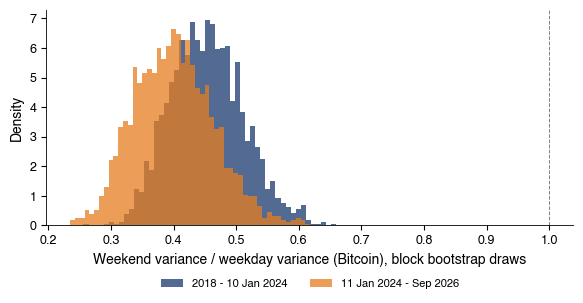

  Daily returns                                      3,182
  Volatility (% a year)                              64.089
  Volatility: 95% CI lower                           58.218
  Volatility: 95% CI upper                           70.374
  S&P 500 volatility, same period (% a year)         19.210
  Volatility ratio to the S&P 500                    3.336
  Weekend / weekday variance ratio, before the ETFs  0.449
  Before: 95% CI lower                               0.349
  Before: 95% CI upper                               0.574
  Weekend / weekday variance ratio, since the ETFs   0.395
  Since: 95% CI lower                                0.289
  Since: 95% CI upper                                0.533
  Change in the ratio (since - before)               -0.055
  Change: 95% CI lower                               -0.224
  Change: 95% CI upper                               0.114


In [13]:
# Solution
def b1_btc_facts(key='BTC'):
    """Annualised volatility relative to the S&P 500 and the weekend effect before / after the ETFs, with a block bootstrap."""
    r = 100 * log_returns(key, '2018-01-01')
    s = 100 * log_returns('SPX', str(r.index[0].date()))
    vc = r.std() * np.sqrt(365)
    vs = s.std() * np.sqrt(252)
    lo, hi, _ = block_boot(r, lambda x: x.std() * np.sqrt(365))
    pre, post = r.loc[:'2024-01-10'], r.loc[ETF_START:]
    rp, rq = weekend_ratio(pre), weekend_ratio(post)
    plo, phi_, dpre = block_boot(pre, weekend_ratio, block=21)
    qlo, qhi, dpost = block_boot(post, weekend_ratio, block=21, seed=SEED + 1)
    diff = dpost - dpre
    return dict(start=str(r.index[0].date()), n=len(r), vol=vc, vol_lo=lo, vol_hi=hi, vol_spx=vs, ratio=vc / vs,
                wr_pre=rp, wr_pre_lo=plo, wr_pre_hi=phi_, wr_post=rq, wr_post_lo=qlo, wr_post_hi=qhi,
                diff=rq - rp, diff_lo=np.percentile(diff, 2.5), diff_hi=np.percentile(diff, 97.5),
                n_pre=len(pre), n_post=len(post), kurt=float(pd.Series(r).kurt()), _dpre=dpre, _dpost=dpost)


def fig_sem_weekend(b1):
    """Bootstrap distributions of the weekend / weekday ratio, before and after the ETFs."""
    fig, ax = plt.subplots(figsize=(6.8, 2.8))
    ax.hist(b1['_dpre'], bins=50, color=MainBlue, alpha=0.75, density=True, label='2018 - 10 Jan 2024')
    ax.hist(b1['_dpost'], bins=50, color=Orange, alpha=0.75, density=True, label='11 Jan 2024 - Sep 2026')
    ax.axvline(1, color=Gray, lw=0.7, ls='--')
    ax.set_xlabel('Weekend variance / weekday variance (Bitcoin), block bootstrap draws')
    ax.set_ylabel('Density')
    legend_outside_bottom(ax, ncol=2, y=-0.2)
    save_fig('ch16_sem_weekend')


b1 = b1_btc_facts('BTC')
fig_sem_weekend(b1)
show(b1, {'n': 'Daily returns',
 'vol': 'Volatility (% a year)',
 'vol_lo': 'Volatility: 95% CI lower',
 'vol_hi': 'Volatility: 95% CI upper',
 'vol_spx': 'S&P 500 volatility, same period (% a year)',
 'ratio': 'Volatility ratio to the S&P 500',
 'wr_pre': 'Weekend / weekday variance ratio, before the ETFs',
 'wr_pre_lo': 'Before: 95% CI lower',
 'wr_pre_hi': 'Before: 95% CI upper',
 'wr_post': 'Weekend / weekday variance ratio, since the ETFs',
 'wr_post_lo': 'Since: 95% CI lower',
 'wr_post_hi': 'Since: 95% CI upper',
 'diff': 'Change in the ratio (since - before)',
 'diff_lo': 'Change: 95% CI lower',
 'diff_hi': 'Change: 95% CI upper'})

### B2. Ether and Solana [Proposed]

- Repeat B1 for Ether and Solana. Model: B1.
- Interpretation: which coin is the riskiest relative to shares?

In [ ]:
# Your code here


### B3. Is the USD Coin peg a threshold process? [Solved]

- Equilibrium threshold AR (EQ-TAR) with a grid-search threshold; $\sup$-Wald linearity test with Hansen's fixed-regressor bootstrap, with and without March 2023.
- Interpretation: why is the $\chi^2_1$ $p$-value wrong, and does one stress week carry the evidence?

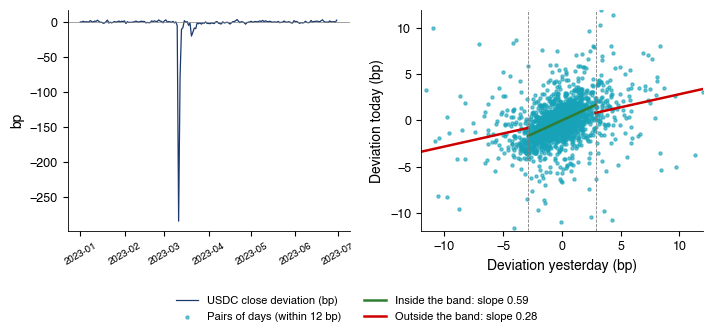

A7
  Days for -285 bp to re-enter the band (exact)  3.647
  Days, rounded up                               4
  Half-life inside (days)                        1.295
  Half-life outside (days)                       0.549


,Full sample,Without 9-16 March 2023
Days,2086.000,2077.000
Threshold c (bp),2.865,2.865
Days outside the band,327.000,322.000
Share of days outside the band (%),15.676,15.503
AR slope inside the band,0.586,0.587
AR slope inside: White SE,0.041,0.041
AR slope outside the band,0.283,0.278
AR slope outside: White SE,0.033,0.125
Half-life inside (days),1.295,1.301
Half-life outside (days),0.549,0.541


In [15]:
# Solution
def b3_usdc(key='USDC', start='2021-01-01'):
    """Daily peg deviation (bp): statistics, equilibrium threshold AR (EQ-TAR) with the sup-Wald test and a
    fixed-regressor bootstrap (Hansen, 1996), with and without the week of 9-16 March 2023."""
    d = read_market(ASSETS[key][0]).loc[start:END]
    dev = 1e4 * (d['close'] - 1)
    ex = dev.drop(dev.loc['2023-03-09':'2023-03-16'].index)
    return dict(key=key, n=len(dev), sd=dev.std(), sd_ex=ex.std(), out50=int((dev.abs() > 50).sum()),
                out50_ex=int((ex.abs() > 50).sum()), min=dev.min(), min_date=str(dev.idxmin().date()),
                low=1e4 * (d['low'].min() - 1), low_date=str(d['low'].idxmin().date()),
                full=I.tar_fit(dev), ex=I.tar_fit(ex), kurt=float(dev.kurt()))


def fig_sem_usdc(tar):
    """USDC: peg deviation in 2023 and today's deviation against yesterday's, with the EQ-TAR lines of each
    regime (estimated threshold c) and the linear AR(1) line."""
    d = read_market(ASSETS['USDC'][0]).loc['2021-01-01':END]
    dev = 1e4 * (d['close'] - 1)
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.9))
    z = dev.loc['2023-01-01':'2023-06-30']
    axes[0].plot(z.index, z.values, color=MainBlue, lw=0.9, label='USDC close deviation (bp)')
    axes[0].axhline(0, color=Gray, lw=0.5)
    axes[0].tick_params(axis='x', labelsize=7, rotation=30)
    axes[0].set_ylabel('bp')
    z1 = pd.concat([dev.shift(1), dev], axis=1).dropna()
    z1.columns = ['lag', 'now']
    zz = z1[(z1.abs() <= 12).all(axis=1)]
    axes[1].scatter(zz['lag'], zz['now'], s=5, color=Teal, alpha=0.6, label='Pairs of days (within 12 bp)')
    c = tar['c']
    xi = np.array([-c, c])
    axes[1].plot(xi, tar['phi_in'] * xi, color=Forest, lw=1.8, label=f'Inside the band: slope {tar["phi_in"]:.2f}')
    for xo in [np.array([-12, -c]), np.array([c, 12])]:
        axes[1].plot(xo, tar['phi_out'] * xo, color=IDAred, lw=1.8)
    axes[1].plot([], [], color=IDAred, lw=1.8, label=f'Outside the band: slope {tar["phi_out"]:.2f}')
    for v in [-c, c]:
        axes[1].axvline(v, color=Gray, lw=0.6, ls='--')
    axes[1].set_xlim(-12, 12)
    axes[1].set_ylim(-12, 12)
    axes[1].set_xlabel('Deviation yesterday (bp)')
    axes[1].set_ylabel('Deviation today (bp)')
    fig.tight_layout()
    fig_legend_bottom(fig, ncol=2, y=0.0)
    save_fig('ch16_sem_usdc')


b3 = b3_usdc('USDC')
fig_sem_usdc(b3['full'])
show(a7_tar(b3['full']), {'n_out': 'Days for -285 bp to re-enter the band (exact)', 'n_days': 'Days, rounded up', 'hl_in': 'Half-life inside (days)', 'hl_out': 'Half-life outside (days)'}, title='A7')
table({k: b3[k] for k in ['full', 'ex']}, {'n': 'Days',
 'c': 'Threshold c (bp)',
 'n_out': 'Days outside the band',
 'share_out': 'Share of days outside the band (%)',
 'phi_in': 'AR slope inside the band',
 'se_in': 'AR slope inside: White SE',
 'phi_out': 'AR slope outside the band',
 'se_out': 'AR slope outside: White SE',
 'hl_in': 'Half-life inside (days)',
 'hl_out': 'Half-life outside (days)',
 'phi_lin': 'Linear AR(1) slope',
 'sup_w': 'sup-Wald statistic',
 'p_boot': 'Bootstrap p-value',
 'chi2_p': 'Chi-squared(1) p-value (not valid here)',
 'share_var_out': 'Share of the sum of squared lagged deviations outside the band (%)'}, {'full': 'Full sample', 'ex': 'Without 9-16 March 2023'})

### B4. Tether and Dai [Proposed]

- Repeat B3 for Tether and Dai. Model: B3.
- Interpretation: which coin reverts fastest outside its band, and what would a test of two thresholds need?

In [ ]:
# Your code here


### B5. IBIT: tracking, timing and the fee drift [Solved]

- Daily, weekly and Dimson betas; ADF and KPSS on the log price ratio; fee drift from differences and from the trend, with HAC errors.
- Interpretation: why is the daily OLS beta below 1, and which drift estimator is precise?

In [18]:
# Solution
def b5_etf(etf='IBIT', coin='BTC'):
    """Tracking: daily vs weekly beta (HAC); the fee drift as the mean of Delta ln(P_ETF/P_coin) with a HAC
    error; ADF (H0: unit root) and KPSS (H0: stationarity around a trend) tests on the level of the ratio;
    comparison with the slope of the level on time; Dimson (1979) beta with one lag and one lead."""
    from statsmodels.tsa.stattools import adfuller, kpss
    t = etf_tracking(etf, coin)
    p = pd.concat([price(etf), price(coin)], axis=1, join='inner').dropna()
    lr = np.log(p[etf] / p[coin])
    yrs = (lr.index[-1] - lr.index[0]).days / 365.25
    dl = lr.diff().dropna()
    ppy = len(dl) / yrs
    L = I.nw_lags(len(dl))
    m0 = sm.OLS(dl.values, np.ones(len(dl))).fit(cov_type='HAC', cov_kwds={'maxlags': L})
    tt = pd.Series((lr.index - lr.index[0]).days / 365.25, index=lr.index)
    m = hac_ols(lr, tt, lags=20)
    adf = adfuller(lr.values, regression='ct', autolag='AIC')
    kp = kpss(lr.values, regression='ct', nlags='auto')
    adf_d = adfuller(dl.values, regression='c', autolag='AIC')
    t.update(drift_mean=100 * ppy * m0.params[0], drift_mse=100 * ppy * m0.bse[0],
             drift_mlo=100 * ppy * (m0.params[0] - 1.96 * m0.bse[0]), drift_mhi=100 * ppy * (m0.params[0] + 1.96 * m0.bse[0]),
             drift_hac=100 * m.params.iloc[1], drift_se=100 * m.bse.iloc[1],
             drift_lo=100 * (m.params.iloc[1] - 1.96 * m.bse.iloc[1]), drift_hi=100 * (m.params.iloc[1] + 1.96 * m.bse.iloc[1]),
             adf=adf[0], adf_p=adf[1], kpss=kp[0], kpss_p=kp[1], adf_d=adf_d[0], adf_d_p=adf_d[1],
             t_beta_w=(t['beta_w'] - 1) / t['se_w'], lags=L, dimson=I.dimson(etf, coin))
    return t


show(b5_etf('IBIT', 'BTC'), {'n_d': 'Common trading days',
 'n_w': 'Weeks',
 'beta_d': 'Daily OLS beta',
 'beta_w': 'Weekly beta',
 'se_w': 'Weekly beta: HAC standard error',
 'dimson/sum': 'Dimson sum beta',
 'dimson/se': 'Dimson sum beta: standard error',
 'dimson/t1': 'Dimson: t-statistic for beta = 1',
 'adf': 'ADF statistic on ln(ETF / coin)',
 'adf_p': 'ADF p-value',
 'kpss': 'KPSS statistic',
 'kpss_p': 'KPSS p-value (table bounded at 0.10)',
 'drift_mean': 'Drift from the mean of daily differences (% a year)',
 'drift_mlo': 'Mean drift: 95% CI lower',
 'drift_mhi': 'Mean drift: 95% CI upper',
 'drift_hac': 'Drift from the trend slope, HAC (% a year)',
 'drift_lo': 'Trend drift: 95% CI lower',
 'drift_hi': 'Trend drift: 95% CI upper',
 'te_d': 'Tracking error, daily (% a year)',
 'te_w': 'Tracking error, weekly (% a year)'})

  Common trading days                                  673
  Weeks                                                140
  Daily OLS beta                                       0.935
  Weekly beta                                          1.007
  Weekly beta: HAC standard error                      0.011
  Dimson sum beta                                      0.998
  Dimson sum beta: standard error                      0.023
  Dimson: t-statistic for beta = 1                     -0.071
  ADF statistic on ln(ETF / coin)                      -11.070
  ADF p-value                                          0.000
  KPSS statistic                                       0.041
  KPSS p-value (table bounded at 0.10)                 0.100
  Drift from the mean of daily differences (% a year)  -0.356
  Mean drift: 95% CI lower                             -9.280
  Mean drift: 95% CI upper                             8.568
  Drift from the trend slope, HAC (% a year)           -0.237
  Trend drift: 95% CI 

### B6. ETHA and Ether [Proposed]

- Repeat B5 for ETHA against Ether. Model: B5.
- Interpretation: is ETHA a worse tracker or only noisier?

In [ ]:
# Your code here


### B7. When did Strategy's Bitcoin beta change? [Solved]

- Weekly two-factor regressions; $\sup$-Wald test for a break at an unknown date with HAC errors; break date and its 95% CI.
- Interpretation: do the data point to January 2024 as the break date?

In [20]:
# Solution
def b7_equity(key='MSTR'):
    """Weekly two-factor regression, the test b_BTC = 1 in subperiods and the sup-Wald test (Andrews, 1993)
    for a break at an unknown date in all three coefficients, with HAC errors and the Bai (1997) CI."""
    out = {}
    # the subperiods partition the full sample: p1 ends the day before the ETFs, p2 starts with them
    for lab, a, b in [('full', '2021-04-16', END), ('p1', '2021-04-16', '2024-01-10'), ('p2', ETF_START, END)]:
        w = joint_returns([key, 'BTC', 'SPX'], None, freq='W').loc[a:b]
        m = hac_ols(w[key], w[['BTC', 'SPX']])
        out[lab] = dict(n=len(w), b_btc=m.params['BTC'], se_btc=m.bse['BTC'], b_spx=m.params['SPX'],
                        se_spx=m.bse['SPX'], r2=m.rsquared, t1=(m.params['BTC'] - 1) / m.bse['BTC'],
                        alpha=52 * 100 * m.params['const'], alpha_t=m.tvalues['const'])
    w = 100 * joint_returns([key, 'BTC', 'SPX'], None, freq='W').loc['2021-04-16':END]
    X = np.column_stack([np.ones(len(w)), w['BTC'].values, w['SPX'].values])
    sw = I.sup_wald(w[key].values, X, w.index)
    Wser = pd.Series(sw.pop('W'), index=w.index)
    crit = I.sup_wald_crit(3)
    sw.update(p=float((crit >= sw['sup_w']).mean()), cv5=float(np.percentile(crit, 95)),
              W_etf=float(Wser.loc[ETF_START:].iloc[0]), W_date=float(Wser.loc[sw['date']]))
    out['sw'] = sw
    # test of the change: full-sample regression with interactions D_t = 1 after the ETF launch, HAC errors (same lags)
    w = joint_returns([key, 'BTC', 'SPX'], None, freq='W').loc['2021-04-16':END]
    D = (w.index >= pd.Timestamp(ETF_START)).astype(float)
    Xi = pd.DataFrame({'BTC': w['BTC'], 'SPX': w['SPX'], 'D': D, 'D_BTC': D * w['BTC'], 'D_SPX': D * w['SPX']}, index=w.index)
    m = hac_ols(w[key], Xi)
    out['chg'] = dict(d_btc=m.params['D_BTC'], se=m.bse['D_BTC'], t=m.tvalues['D_BTC'], p=m.pvalues['D_BTC'])
    return out


b7 = b7_equity('MSTR')
show(b7['sw'], {'sup_w': 'sup-Wald statistic',
 'cv5': '5% critical value',
 'p': 'p-value',
 'date': 'Least-squares break date',
 'ci_lo': 'Break date: 95% CI lower',
 'ci_hi': 'Break date: 95% CI upper',
 'W_etf': 'Wald statistic at the ETF launch (January 2024)'})
table({k: b7[k] for k in ['full', 'p1', 'p2']}, {'n': 'Weeks',
 'b_btc': 'Beta on Bitcoin',
 'se_btc': 'Beta on Bitcoin: HAC standard error',
 't1': 't-statistic for Bitcoin beta = 1',
 'b_spx': 'Beta on the S&P 500',
 'se_spx': 'Beta on the S&P 500: HAC standard error',
 'r2': 'R squared',
 'alpha': 'Alpha (% a year)',
 'alpha_t': 't-statistic of alpha'}, {'full': 'Full sample', 'p1': 'Before the ETFs', 'p2': 'Since the ETFs'})

  sup-Wald statistic                               35.488
  5% critical value                                13.946
  p-value                                          0.000
  Least-squares break date                         2022-06-24
  Break date: 95% CI lower                         2021-12-31
  Break date: 95% CI upper                         2022-12-16
  Wald statistic at the ETF launch (January 2024)  8.642


,Full sample,Before the ETFs,Since the ETFs
Weeks,284.000,143.000,141.000
Beta on Bitcoin,1.179,1.011,1.504
Beta on Bitcoin: HAC standard error,0.109,0.137,0.122
t-statistic for Bitcoin beta = 1,1.642,0.082,4.122
Beta on the S&P 500,1.024,1.404,0.477
Beta on the S&P 500: HAC standard error,0.241,0.351,0.290
R squared,0.630,0.649,0.652
Alpha (% a year),-4.513,-0.743,-9.275
t-statistic of alpha,-0.188,-0.025,-0.292


### B8. Coinbase [Proposed]

- Repeat B7 for Coinbase. Model: B7.
- Interpretation: do Strategy and Coinbase have their break at the same date?

In [ ]:
# Your code here


## Part C — open questions and AI critique

### C1. Alternative asset, risk asset or hedge? [Proposed]

- Is Bitcoin an alternative asset, a risk asset or a hedge? Evidence since the spot ETFs, against January 2021 – January 2024.
- Correlations with block-bootstrap intervals; hedge and safe-haven regression; downside beta; Forbes–Rigobon adjusted correlation; quantile-regression betas. Model: B1, B5.

In [ ]:
# Your code here


### C2. Critique an AI answer [Proposed]

- An AI assistant compared Bitcoin with lending USD Coin at 5% a year: log returns on prices cut to 2021–2025, annualised with 252 days, the 5% USD Coin yield as the risk-free rate; it concluded that lending USD Coin is a risk-free investment.
- Tasks: find the five substantive errors (three in the code, two in the text); say how you would detect each one; write the corrected code and report the annualised mean, volatility and Sharpe ratio; log every error in the format of `AI_ERRORS.md`. Model: B1, B3.

In [ ]:
# Your code here


### C3. Crypto factors after July 2020 [Proposed]

- Out of sample, does three-week momentum among large coins survive, and is the crypto market still segmented from equities? Context: Liu, Tsyvinski & Wu (2022).
- Tasks: weekly returns on the paper's calendar compared with Table 1, Panel B; regression of the excess return of the five-coin index on the five global factors and five currencies (footnote 16 of the paper), in and out of sample; three-week momentum (top three minus bottom three coins) with the crypto CAPM; a change in alpha after July 2020 and a $\sup$-Wald break test. Model: B5, B7.

In [ ]:
# Your code here
